# Imports

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import contractions

# Initialize the tools
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7667.83it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Data Imports

In [3]:
df = pd.read_csv("iphone.csv")
df.head()

,productAsin,country,date,isVerified,ratingScore,reviewTitle,reviewDescription,reviewUrl,reviewedIn,variant,variantAsin
0,B09G9BL5CP,India,11-08-2024,True,4,No charger,"Every thing is good about iPhones, there's not...",https://www.amazon.in/gp/customer-reviews/R345...,Reviewed in India on 11 August 2024,Colour: MidnightSize: 256 GB,B09G9BQS98
1,B09G9BL5CP,India,16-08-2024,True,5,iPhone 13 256GB,"It look so fabulous, I am android user switche...",https://www.amazon.in/gp/customer-reviews/R2HJ...,Reviewed in India on 16 August 2024,Colour: MidnightSize: 256 GB,B09G9BQS98
2,B09G9BL5CP,India,14-05-2024,True,4,Flip camera option nill,I tried to flip camera while recording but no ...,https://www.amazon.in/gp/customer-reviews/R3Y7...,Reviewed in India on 14 May 2024,Colour: MidnightSize: 256 GB,B09G9BQS98
3,B09G9BL5CP,India,24-06-2024,True,5,Product,100% genuine,https://www.amazon.in/gp/customer-reviews/R1P9...,Reviewed in India on 24 June 2024,Colour: MidnightSize: 256 GB,B09G9BQS98
4,B09G9BL5CP,India,18-05-2024,True,5,Good product,Happy to get the iPhone 13 in Amazon offer,https://www.amazon.in/gp/customer-reviews/R1XI...,Reviewed in India on 18 May 2024,Colour: MidnightSize: 256 GB,B09G9BQS98


# Data Cleaning

In [4]:
df = df.dropna() # Dropping the null rows since we cannot generate review data.
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 2960 entries, 0 to 3061
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   productAsin        2960 non-null   str  
 1   country            2960 non-null   str  
 2   date               2960 non-null   str  
 3   isVerified         2960 non-null   bool 
 4   ratingScore        2960 non-null   int64
 5   reviewTitle        2960 non-null   str  
 6   reviewDescription  2960 non-null   str  
 7   reviewUrl          2960 non-null   str  
 8   reviewedIn         2960 non-null   str  
 9   variant            2960 non-null   str  
 10  variantAsin        2960 non-null   str  
dtypes: bool(1), int64(1), str(9)
memory usage: 1.5 MB


In [5]:
df = df.drop(columns=["productAsin","country","date","reviewUrl","reviewedIn","variantAsin","variant"])#Variant column is dropped for simplicity purpose, 
                                                                                                    #else it would have been cleaned and used as metadata
df.rename(columns={"ratingScore":"target"},inplace=True)
df.head()

,isVerified,target,reviewTitle,reviewDescription
0,True,4,No charger,"Every thing is good about iPhones, there's not..."
1,True,5,iPhone 13 256GB,"It look so fabulous, I am android user switche..."
2,True,4,Flip camera option nill,I tried to flip camera while recording but no ...
3,True,5,Product,100% genuine
4,True,5,Good product,Happy to get the iPhone 13 in Amazon offer


In [6]:
df.isVerified.value_counts()

isVerified
True     2761
False     199
Name: count, dtype: int64

In [7]:
df = df[df['isVerified'] == True] # Dropping the rows where isVerified column value is False, since they aren't authenticated reviews.

In [8]:
df.isVerified.value_counts()
df = df.drop(columns=["isVerified"])

In [9]:
df.sample(5)

,target,reviewTitle,reviewDescription
1083,4,Does the job,I've switched from iPhone 13 to 15 and this tr...
2655,5,Good,Liked the product for its design and color. Ca...
1657,5,Compra buena,es super bueno caja generica y tu recibo y ins...
1570,5,Nice phone!,Great looking phone out of the box with tiny s...
2558,5,Apple iPhone 13 (256GB) - Starlight,I am very pleased that I bought the original i...


## Data Cleaning completed, now these two columns will be processed for NLP

In [10]:
def process_review(text):
    if not isinstance(text, str):
        return ""

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs and HTML tags
    text = re.sub(r'http\S+|www\S+|<.*?>', '', text)

    # Keep alphanumeric characters and basic punctuation (.,!?)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)
    
    return text.strip()


In [11]:
# Combine title and description for full context
df['combined_text'] = df.apply(lambda row: f"Review Title: {row['reviewTitle']}. Review Body: {row['reviewDescription']}", axis=1)

# Apply the transformation
df['processed_string'] = df['combined_text'].apply(process_review)

df.processed_string.head()

0    Review Title No charger. Review Body Every thi...
1    Review Title iPhone 13 256GB. Review Body It l...
2    Review Title Flip camera option nill. Review B...
3        Review Title Product. Review Body 100 genuine
4    Review Title Good product. Review Body Happy t...
Name: processed_string, dtype: str

In [12]:

# Test on a custom string to verify your pattern
test_input = "I LOVE this iPhone!!! Better than my last one ❤️ http://apple.com"
print(f"Input: {test_input}")
print(f"Output: {process_review(test_input)}")


Input: I LOVE this iPhone!!! Better than my last one ❤️ http://apple.com
Output: I LOVE this iPhone!!! Better than my last one


## Generating and storing the embeddings

In [13]:
# Generate the embeddings
# This creates a large numpy array where each row is a 384-dimensional vector
embeddings = model.encode(df['processed_string'].tolist(), show_progress_bar=True)

# Add the embeddings to your dataframe
# We convert the numpy array to a list so it fits into a single column
df['embeddings'] = list(embeddings)

print(f"Embedding shape: {embeddings.shape}") # Should be (number_of_rows, 384)


Batches: 100%|██████████| 87/87 [00:02<00:00, 29.54it/s]

Embedding shape: (2761, 384)


## Visualizing the embeddings using t-SNE

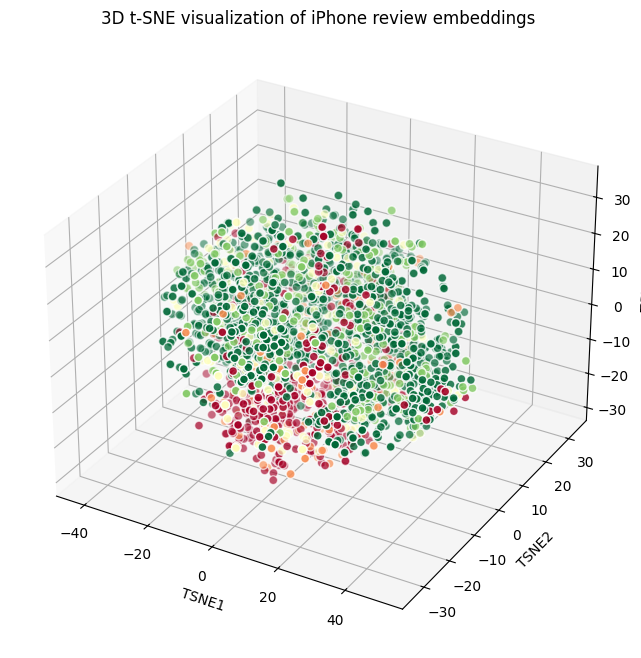

In [14]:
# 1. Update t-SNE to 3 components
tsne = TSNE(n_components=3, random_state=42)
embeddings_3d = tsne.fit_transform(embeddings)

# 2. Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot points
scatter = ax.scatter(
    embeddings_3d[:, 0], 
    embeddings_3d[:, 1], 
    embeddings_3d[:, 2], 
    c=df['target'].astype('category').cat.codes, 
    cmap='RdYlGn', 
    s=40,
    edgecolor='w'
)

# 4. Labels and Title
ax.set_title('3D t-SNE visualization of iPhone review embeddings')
ax.set_xlabel('TSNE1')
ax.set_ylabel('TSNE2')
ax.set_zlabel('TSNE3')

plt.show()

## Saving the data

In [15]:
# Save the array to a .npy file
np.save("review_embeddings.npy", embeddings)

print(f"Vectors saved! Shape: {embeddings.shape}")

Vectors saved! Shape: (2761, 384)


In [16]:
# Drop the embeddings column so the CSV stays lightweight
df_metadata = df.drop(columns=['embeddings','reviewTitle','reviewDescription','processed_string','combined_text'])

# Save as a standard CSV
df_metadata.to_csv("review_metadata.csv", index=False)

print("Metadata (Text/IDs) saved to review_metadata.csv")


Metadata (Text/IDs) saved to review_metadata.csv
